# Anomaly Flight Logs Data Cleaning

## Import Statements

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [194]:
# Data structures
import pandas as pd
import numpy as np

# Import visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML tools
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Import tools for preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Import metrics to evaluate performance
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.metrics import average_precision_score

# Save model
import joblib

## Get the two datasets

### Get the base dataset showing flight paths and anomalies from structured logs:

In [40]:
# Get the flight path anomaly dataset
path03 = "/Users/ladylo/PycharmProjects/FlightForensics/data/processed/logs/flight/DF061/anomaly_detection/cleaned_18-06-19-02-04-47_anomaly_log.csv"

path04 = '/Users/ladylo/PycharmProjects/FlightForensics/data/processed/logs/flight/DF061/anomaly_detection/cleaned_18-06-19-02-11-31_anomaly_log.csv'

flight03_path = pd.read_csv(path03)
flight04_path = pd.read_csv(path04)

In [41]:
# Convert flight path anomaly dataset into DataFrame format
flight03_anomaly = pd.DataFrame(flight03_path)
flight04_anomaly = pd.DataFrame(flight04_path)

In [42]:
# Add flight sequence to each column to show two separate flights
flight03_anomaly["flight_sequence"] = "flight03"
flight04_anomaly["flight_sequence"] = "flight04"

In [43]:
# Combine datasets
flight_anomaly = pd.concat([flight03_anomaly, flight04_anomaly])

In [44]:
# Look at the first five rows
flight_anomaly.head()

,clock_offset,imu_longitude,imu_latitude,imu_rel_height,roll,pitch,yaw,accel_x,accel_y,accel_z,...,hover_point_uncertainty2,hover_point_uncertainty3,hover_point_uncertainty4,hover_point_uncertainty5,hover_point_uncertainty6,velocity_uncertainty1,velocity_uncertainty3,velocity_uncertainty4,velocity_uncertainty6,flight_sequence
0,-344.350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,flight03
1,0.000,-106.216454,39.961194,-2.224854,1.097724,-2.153399,-117.847337,-0.037371,-0.019999,-1.008184,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03
2,0.039,-106.216454,39.961194,-0.546142,1.119289,-2.155384,-117.846310,-0.036579,-0.020031,-1.008412,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03
3,0.101,-106.216454,39.961194,-0.546142,1.119289,-2.155384,-117.846310,-0.036579,-0.020031,-1.008412,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03
4,0.143,-106.216454,39.961194,-0.959717,1.119977,-2.177045,-118.033396,-0.030232,-0.039988,-1.011359,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03


### Clean up the datatypes

In [45]:
# Check flight_anomaly data types
flight_anomaly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9045 entries, 0 to 5621
Data columns (total 69 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   clock_offset               9045 non-null   float64
 1   imu_longitude              9042 non-null   float64
 2   imu_latitude               9042 non-null   float64
 3   imu_rel_height             3422 non-null   float64
 4   roll                       9042 non-null   float64
 5   pitch                      9042 non-null   float64
 6   yaw                        9042 non-null   float64
 7   accel_x                    9042 non-null   float64
 8   accel_y                    9042 non-null   float64
 9   accel_z                    9042 non-null   float64
 10  accel_composite            9042 non-null   float64
 11  gyro_x                     9042 non-null   float64
 12  gyro_z                     9042 non-null   float64
 13  gyro_composite             9042 non-null   float64
 1

In [46]:
# Convert gps_timestamp to dateTime format
flight_anomaly["gps_timestamp"] = pd.to_datetime(flight_anomaly["gps_timestamp"], errors="coerce", utc=True)

In [47]:
# Convert the objects into boolean data types
boolean_columns = ["pos_error", "oa_emergency_brake"]
flight_anomaly[boolean_columns] = flight_anomaly[boolean_columns].astype(bool)

In [123]:
# Force conversion to string
flight_anomaly["control_mode"] = flight_anomaly["control_mode"].astype("string")
flight_anomaly["flight_sequence"] = flight_anomaly["flight_sequence"].astype("string")

In [124]:
# Check for successful conversions
flight_anomaly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9045 entries, 0 to 5621
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   clock_offset               9045 non-null   float64            
 1   imu_longitude              9042 non-null   float64            
 2   imu_latitude               9042 non-null   float64            
 3   roll                       9042 non-null   float64            
 4   pitch                      9042 non-null   float64            
 5   yaw                        9042 non-null   float64            
 6   accel_x                    9042 non-null   float64            
 7   accel_y                    9042 non-null   float64            
 8   accel_z                    9042 non-null   float64            
 9   accel_composite            9042 non-null   float64            
 10  gyro_x                     9042 non-null   float64            
 11  gyro_z   

### Check missing values

In [125]:
flight_anomaly.isna().sum()

,0
clock_offset,0
imu_longitude,3
imu_latitude,3
roll,3
pitch,3
...,...
velocity_uncertainty4,4
velocity_uncertainty6,4
flight_sequence,0
anomaly_label,0


In [55]:
# drop imu_rel_height attribute
flight_anomaly.drop("imu_rel_height", axis=1, inplace=True)

In [69]:
# Obtain only numeric features
numeric_features = flight_anomaly.select_dtypes(include=["int64", float])

# Use interpolation to fix null values in numeric attributes
numeric_features = numeric_features.interpolate(method="linear", limit_direction="both")


In [70]:
# Check if there is any missed NaN values
numeric_features.isna().sum()

,0
clock_offset,0
imu_longitude,0
imu_latitude,0
roll,0
pitch,0
...,...
hover_point_uncertainty6,0
velocity_uncertainty1,0
velocity_uncertainty3,0
velocity_uncertainty4,0


## Initialize & Train the Unsupervised Model

Unsupervised learning method using isolation forests to create labels to train a supervised learning model later.

In [74]:
# Initialize model
iso = IsolationForest(contamination=0.02, random_state=42)

In [75]:
# Train the unsupervised model
iso.fit(numeric_features)

IsolationForest(contamination=0.02, random_state=42)

In [76]:
# Get predictions
labels = iso.predict(numeric_features)
scores = iso.decision_function(numeric_features)

In [79]:
flight_anomaly["anomaly_label"] = labels
flight_anomaly["anomaly_score"] = scores

In [89]:
flight_anomaly[flight_anomaly["anomaly_label"] == -1]

,clock_offset,imu_longitude,imu_latitude,roll,pitch,yaw,accel_x,accel_y,accel_z,accel_composite,...,hover_point_uncertainty4,hover_point_uncertainty5,hover_point_uncertainty6,velocity_uncertainty1,velocity_uncertainty3,velocity_uncertainty4,velocity_uncertainty6,flight_sequence,anomaly_label,anomaly_score
65,3.305,-106.216446,39.961194,3.532821,-7.764505,-116.070895,-0.153464,-0.024046,-1.058298,1.069638,...,0.010951,0.0,0.010951,0.000684,0.349161,0.000684,0.000684,flight03,-1,-0.015774
66,3.346,-106.216446,39.961194,4.856909,-6.269127,-115.695772,-0.158478,-0.009237,-1.014475,1.026821,...,0.010951,0.0,0.010951,0.000684,0.349161,0.000684,0.000684,flight03,-1,-0.010449
67,3.398,-106.216446,39.961194,4.856909,-6.269127,-115.695772,-0.158478,-0.009237,-1.014475,1.026821,...,0.010951,0.0,0.010951,0.000684,0.349161,0.000684,0.000684,flight03,-1,-0.010449
68,3.434,-106.216446,39.961194,4.856909,-6.269127,-115.695772,-0.158478,-0.009237,-1.014475,1.026821,...,0.010951,0.0,0.010951,0.000684,0.349161,0.000684,0.000684,flight03,-1,-0.010449
69,3.477,-106.216445,39.961194,3.606063,-7.066203,-115.641181,-0.066674,-0.043700,-1.030997,1.034074,...,0.010951,0.0,0.010951,0.000684,0.349161,0.000684,0.000684,flight03,-1,-0.011142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3274,668.513,-106.217679,39.962830,24.675989,15.403615,113.541988,0.159484,-0.254720,-0.307136,0.429709,...,0.032000,0.0,0.032000,0.002000,0.686517,0.002000,0.002000,flight04,-1,-0.002842
3275,668.551,-106.217679,39.962830,24.675989,15.403615,113.541988,0.159484,-0.254720,-0.307136,0.429709,...,0.032000,0.0,0.032000,0.002000,0.685724,0.002000,0.002000,flight04,-1,-0.002430
4172,706.893,-106.217005,39.960910,-1.294525,-4.804270,59.543143,-0.106238,0.107759,-1.626882,1.633904,...,0.032000,0.0,0.032000,0.002000,0.957045,0.002000,0.002000,flight04,-1,-0.000161
4173,706.931,-106.217005,39.960910,-1.294525,-4.804270,59.543143,-0.106238,0.107759,-1.626882,1.633904,...,0.032000,0.0,0.032000,0.002000,0.957045,0.002000,0.002000,flight04,-1,-0.000161


## Train the Supervised Learning Model

### Preprocess data

Now that we've created labels, prepare the data for training:

In [137]:
# Split up training and test sets
  # Drop columns that are incompatible or risks data leakage
X = flight_anomaly.drop(["anomaly_label", "anomaly_score", "flight_sequence",
                         "control_mode", "gps_timestamp"], axis=1)
y = flight_anomaly["anomaly_label"]

In [138]:
# Check for imbalanced classes
y.value_counts()

,count
anomaly_label,
1,8864
-1,181


In [139]:
# Ensure compatible values in y
y = y.replace({-1: 1, 1:0})

In [140]:
y.value_counts()

,count
anomaly_label,
0,8864
1,181


In [141]:
# Implement stratify splitting to handle imbalance
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

### Initialize and train the XGBoost model

In [142]:
param_grid = {
    "max_depth": [3, 6, 10],
    "learning_rate": [0.1, 0.01, 0.05],
    "n_estimators": [50, 100],
    "scale_pos_weight": [10, 25, 50]
}

In [143]:
xgb = XGBClassifier(
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
    )

In [144]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1",
    n_jobs=-1,
    cv=5,
    verbose=1
)

In [145]:
# train the model
grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:30:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.05],
                         'max_depth': [3, 6, 10], 'n_estimators': [50, 100],
                         'scale_pos_weight': [10, 25, 50]},
             scoring='f1', verbose=1)

In [181]:
# predict on test set
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

In [147]:
# See the best model and parameters
bes_model = grid.best_estimator_
best_params = grid.best_params_

print("Best Model:", bes_model)
print("Best Parameters:", best_params)

Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'scale_pos_weight': 50}


In [156]:
# Check accuracy
grid.score(X_test, y_test)

0.8947368421052632

In [157]:
# Check loss
log_loss(y_test, y_pred)

0.15939702991317725

In [184]:
# Check performance summary
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1773
           1       0.85      0.94      0.89        36

    accuracy                           1.00      1809
   macro avg       0.92      0.97      0.95      1809
weighted avg       1.00      1.00      1.00      1809



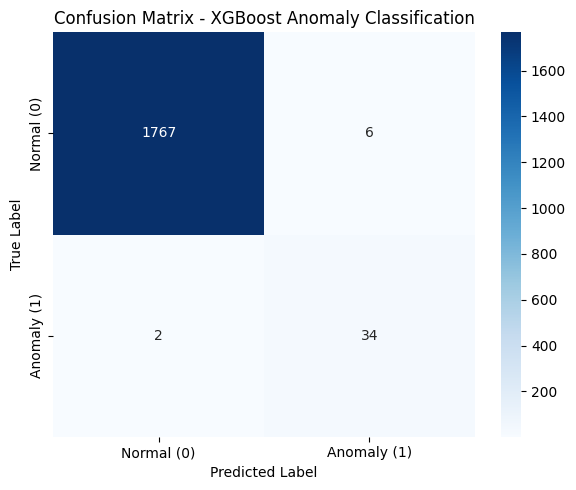

In [161]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Normal (0)", "Anomaly (1)"]

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost Anomaly Classification")
plt.tight_layout()
plt.show()

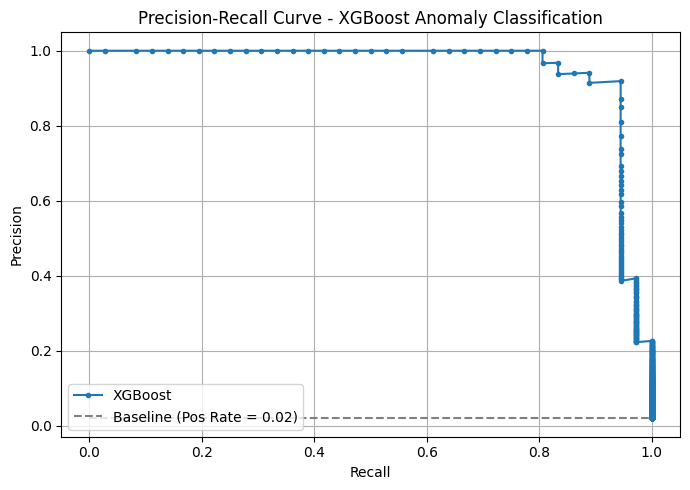

In [190]:

# Compute precision-recall values using probabilities
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
baseline = y_test.mean()

# Plot the PR curve with baseline
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, marker='.', label=f"XGBoost")
plt.hlines(baseline, 0, 1, linestyles="dashed", colors="gray", label=f"Baseline (Pos Rate = {baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost Anomaly Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

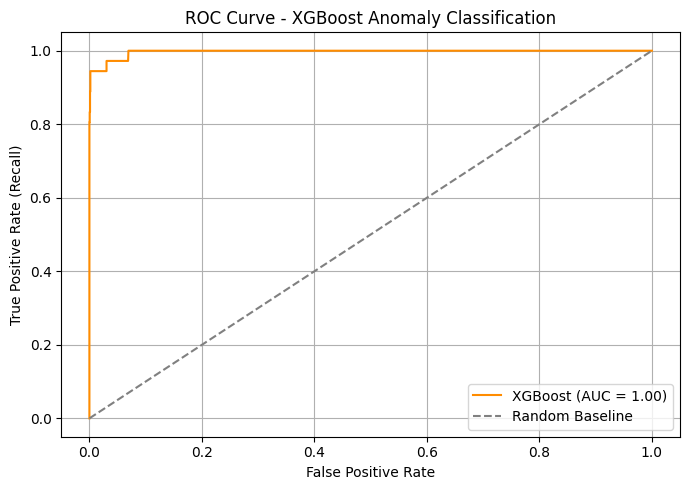

In [189]:
# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - XGBoost Anomaly Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [195]:
# Save the model
joblib.dump(xgb, "xgb_anomaly_model.pkl")

['xgb_anomaly_model.pkl']

In [196]:
!pip install nbconvert
# You also need to install latex-related package in order to convert a notebook to pdf file.
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono fonts-texgyre
  fonts-urw-base35 libapache-pom-java libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3
  libcommons-logging-java libcommons-parent-java libfontbox-java libfontenc1 libgs9 libgs9-common
  libidn12 libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0 libsynctex2
  libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13 lmodern pandoc-data poppler-data
  preview-latex-style rake ruby ruby-net-telnet ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0
  rubygems-integration t1utils teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended texlive-pictures
  texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-fre

In [ ]:
!cp drive/MyDrive/Colab\ Notebooks/flight_anomaly_model.ipynb ./
!jupyter nbconvert --to pdf flight_anomaly_model.ipynb

cp: cannot stat 'drive/MyDrive/Colab Notebooks/Your_File_Name.ipynb': No such file or directory
